In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
n_a = 3
n_b = 3
sigma_0s = [2, 3, 4]

expected_rates = np.array([n_a * n_b * sigma_0 * (0.5 if i != 2 else 1) for i, sigma_0 in enumerate(sigma_0s)])
print(expected_rates)
ppe_vals = np.array([10**(i + 1) for i in range(5)])
rates = np.zeros((len(ppe_vals), 3))
errors = np.zeros_like(rates)
print(rates.shape)
for i, ppe in enumerate(ppe_vals):
    file_name = f"data/{ppe:d}_ppe.csv"
    data = pd.read_csv(f"data/{ppe:d}_ppe.csv")
    rates[i][0] = data["A_A_reaction_rate"].to_numpy()[1:].mean()
    rates[i][1] = data["B_B_reaction_rate"].to_numpy()[1:].mean()
    rates[i][2] = data["A_B_reaction_rate"].to_numpy()[1:].mean()

    errors[i] = rates[i] - expected_rates

print(rates)
print(errors)

[ 9.  13.5 36. ]
(5, 3)
[[ 8.1      12.12     36.      ]
 [ 8.91     13.362    36.      ]
 [ 8.991    13.4865   36.      ]
 [ 8.9991   13.49865  36.      ]
 [ 8.99991  13.499862 36.      ]]
[[-9.00000000e-01 -1.38000000e+00  0.00000000e+00]
 [-9.00000000e-02 -1.38000000e-01  1.00897068e-12]
 [-9.00000000e-03 -1.35000000e-02  1.00897068e-12]
 [-8.99999999e-04 -1.35000001e-03 -1.39976919e-11]
 [-9.00000000e-05 -1.37999904e-04 -1.33994149e-10]]


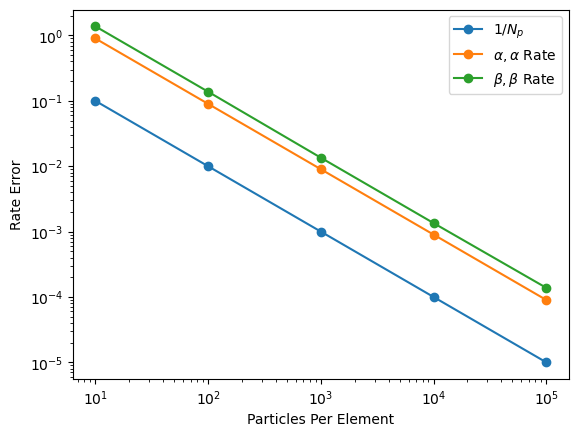

In [9]:
plt.figure()
plt.loglog(ppe_vals, 1 / ppe_vals, '-o', label="$1 / N_p$")
plt.loglog(ppe_vals, np.abs(errors[:, 0]), '-o', label="$\\alpha, \\alpha$ Rate")
plt.loglog(ppe_vals, np.abs(errors[:, 1]), '-o', label="$\\beta, \\beta$ Rate")
plt.legend()
plt.xlabel("Particles Per Element")
plt.ylabel("Rate Error")
plt.show()